**Članovi grupe: Petar Kuruc, Klara Zagajski i Lucija Čorak**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import imblearn

**1. Učitavanje dataset-a**

In [2]:
dataset = pd.read_csv("heart_disease_uci.csv")

dataset.head(10)
# https://pythonguides.com/get-first-n-rows-of-pandas-dataframe/

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


**2. Pronalaženje i odstranjivanje monotonih i konstantnih vrijednosti**

In [4]:
konst_vrijednosti = []
for i in dataset.columns:
    br_drugacijih = dataset[i].nunique()
    if br_drugacijih == 1:
        konst_vrijednosti.append(i)
print(f"Konstantni stupci su: {konst_vrijednosti}")
# https://www.geeksforgeeks.org/pandas-dataframe-remove-constant-columns/

mon_vrijednosti = []
for i in dataset.columns:
    if dataset[i].is_monotonic_decreasing or dataset[i].is_monotonic_increasing:
        mon_vrijednosti.append(i)
print(f"Monotoni stupci su: {mon_vrijednosti}")

Konstantni stupci su: []
Monotoni stupci su: ['id', 'dataset']


In [5]:
dataset2 = dataset.drop(["id", "dataset"], axis=1)
dataset2.head(15)
# https://www.geeksforgeeks.org/how-to-drop-one-or-multiple-columns-in-pandas-dataframe/

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,56,Male,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,62,Female,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,57,Female,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,63,Male,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,53,Male,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


**3. Null vrijednosti**

In [6]:
broj_redaka = dataset2.shape[0]
print(f"Ukupan broj redaka u datasetu je: {broj_redaka}")
dataset2.isnull().sum()

Ukupan broj redaka u datasetu je: 920


age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Kao što vidimo, ima puno nedostajućih vrijednosti u različitim varijablama. Potrebno je provesti razne statističke metode kako bismo došli do potpunog dataset-a, pa je to sljedeće na redu za svaku od značajki.

In [7]:
missing_bp = dataset2[dataset2['trestbps'].isna()]
print(missing_bp)

     age     sex               cp  trestbps   chol    fbs           restecg  \
393   48  Female  atypical angina       NaN  308.0  False  st-t abnormality   
599   35    Male     asymptomatic       NaN    0.0    NaN            normal   
714   69    Male     asymptomatic       NaN    0.0  False  st-t abnormality   
733   63    Male      non-anginal       NaN    0.0  False    lv hypertrophy   
743   74    Male      non-anginal       NaN    0.0  False            normal   
746   51    Male     asymptomatic       NaN    0.0   True  st-t abnormality   
749   55    Male      non-anginal       NaN  228.0  False  st-t abnormality   
750   54    Male     asymptomatic       NaN    0.0  False  st-t abnormality   
756   60    Male     asymptomatic       NaN  281.0  False  st-t abnormality   
758   58    Male     asymptomatic       NaN  203.0   True            normal   
762   61    Male     asymptomatic       NaN    0.0   True  st-t abnormality   
764   57    Male     asymptomatic       NaN  277.0  

Uočavamo da postoje neki retci koji imaju više NaN vrijednosti pa ćemo pronaći sve one koji imaju više od jedne nedostajeće vrijednosti.

In [ ]:
redci_s_vise_nan = dataset2[dataset2.isna().sum(axis=1) > 1]
print("Redci s više od jedne NaN vrijednosti:")
print(redci_s_vise_nan)

print(f"\nBroj redaka s više od jedne NaN vrijednosti: {len(redci_s_vise_nan)}")
print(f"Ukupan broj redaka u datasetu: {len(dataset2)}")
print(f"Postotak redaka s više od jedne NaN vrijednosti: {(len(redci_s_vise_nan))/ (len(dataset2)) * 100:.2f}%")

Redci s više od jedne NaN vrijednosti:
     age     sex               cp  trestbps   chol    fbs           restecg  \
303   28    Male  atypical angina     130.0  132.0  False    lv hypertrophy   
304   29    Male  atypical angina     120.0  243.0  False            normal   
305   29    Male  atypical angina     140.0    NaN  False            normal   
306   30  Female   typical angina     170.0  237.0  False  st-t abnormality   
307   31  Female  atypical angina     100.0  219.0  False  st-t abnormality   
..   ...     ...              ...       ...    ...    ...               ...   
915   54  Female     asymptomatic     127.0  333.0   True  st-t abnormality   
916   62    Male   typical angina       NaN  139.0  False  st-t abnormality   
917   55    Male     asymptomatic     122.0  223.0   True  st-t abnormality   
918   58    Male     asymptomatic       NaN  385.0   True    lv hypertrophy   
919   62    Male  atypical angina     120.0  254.0  False    lv hypertrophy   

     thalch 

60% naših podataka ima više od jedne NaN vrijednosti. To je izrazito puno i sada se suočavamo s problemom kako nadopuniti te praznine.

Prvo ćemo pronaći one retke koji imaju više od tri NaN vrijednosti, pošto su to već dosta nepotpuni podaci za jedan primjer.

In [ ]:
redci_s_vise_od3_nan = dataset2[dataset2.isna().sum(axis=1) > 3]
print("Redci s više od tri NaN vrijednosti:")
print(redci_s_vise_od3_nan)

print(f"\nBroj redaka s više od tri NaN vrijednosti: {len(redci_s_vise_od3_nan)}")
print(f"Ukupan broj redaka u datasetu: {len(dataset2)}")
print(f"Postotak redaka s više od tri NaN vrijednosti: {(len(redci_s_vise_od3_nan))/ (len(dataset2)) * 100:.2f}%")

Redci s više od tri NaN vrijednosti:
     age     sex               cp  trestbps   chol    fbs           restecg  \
305   29    Male  atypical angina     140.0    NaN  False            normal   
330   38  Female  atypical angina     120.0  275.0    NaN            normal   
337   39    Male  atypical angina     130.0    NaN  False            normal   
347   40    Male      non-anginal     140.0    NaN  False            normal   
375   45  Female  atypical angina     180.0    NaN  False            normal   
..   ...     ...              ...       ...    ...    ...               ...   
894   63    Male  atypical angina       NaN  165.0  False  st-t abnormality   
901   55    Male      non-anginal       NaN    NaN  False  st-t abnormality   
905   61    Male      non-anginal       NaN  284.0  False            normal   
916   62    Male   typical angina       NaN  139.0  False  st-t abnormality   
918   58    Male     asymptomatic       NaN  385.0   True    lv hypertrophy   

     thalch  e

9% podataka s više od tri NaN vrijednosti se čini kao dovoljno mali udio podataka koji bi se mogao ukloniti, bez da se značajno smanji dataset. Stoga ću te retke ukloniti.

In [10]:
dataset3 = dataset2[dataset2.isna().sum(axis=1) <= 3]

print(f"\nBroj preostalih redaka nakon uklanjanja: {len(dataset3)}")
print(f"Postotak redaka s više od jedne NaN vrijednosti: {(len(dataset3[dataset3.isna().sum(axis=1) > 1]))/ (len(dataset3)) * 100:.2f}%")
dataset3.isnull().sum()


Broj preostalih redaka nakon uklanjanja: 834
Postotak redaka s više od jedne NaN vrijednosti: 55.28%


age           0
sex           0
cp            0
trestbps      2
chol         10
fbs          80
restecg       0
thalch        0
exang         0
oldpeak       2
slope       225
ca          525
thal        405
num           0
dtype: int64

Vidimo da nam najviše vrijednosti fali za varijable 'ca' i 'thal'. Pošto se radi o medicinskim podatcima i rezultatima testova koji mogu znatno ukazati na neku bolest srca, bolje bi bilo da se NaN vrijednosti nadopune, a ne uklone.

Pošto mi nije u planu ukloniti išta više od NaN vrijednosti nego ih zamijeniti, prvo ćemo pretvoriti sve kategoričke varijable u numeričke i onda primijenitit kNN model na dataset kako bismo nadopunili dataset, po uzoru na popratni članak istraživanja.

**4. Pretvaranje kategoričkih varijabli u numeričke**

In [11]:
numericke_varijable = dataset3.select_dtypes(include=['number']).columns
print("Numeričke varijable:", numericke_varijable.tolist())

kategoričke_varijable = dataset3.select_dtypes(include=['object', 'category']).columns
print("Kategoričke varijable:", kategoričke_varijable.tolist())

Numeričke varijable: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']
Kategoričke varijable: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [12]:
dataset4 = dataset3.copy()

sex_map = {"Male": 0, "Female": 1}
dataset4["sex"] = dataset4["sex"].map(sex_map)

cp_map = {"non-anginal": 0, "asymptomatic": 1, "typical angina": 2, "atypical angina": 3}
dataset4["cp"] = dataset4["cp"].map(cp_map)

dataset4["fbs"] = dataset4["fbs"].replace({True: 1, False: 0})

restecg_map = {"normal": 0, "st-t abnormality": 1, "lv hypertrophy": 2}
dataset4["restecg"] = dataset4["restecg"].map(restecg_map)

dataset4["exang"] = dataset4["exang"].astype(int)

slope_map = {"upsloping": 0, "flat": 1, "downsloping": 2}
dataset4["slope"] = dataset4["slope"].map(slope_map)

thal_map = {"normal": 0, "reversable defect": 1, "fixed defect": 2}
dataset4["thal"] = dataset4["thal"].map(thal_map)

dataset4.head(400)

C:\Users\Lucija\AppData\Local\Temp\ipykernel_28320\2120123599.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset4["fbs"] = dataset4["fbs"].replace({True: 1, False: 0})


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,0,2,145.0,233.0,1.0,2,150.0,0,2.3,2.0,0.0,2.0,0
1,67,0,1,160.0,286.0,0.0,2,108.0,1,1.5,1.0,3.0,0.0,2
2,67,0,1,120.0,229.0,0.0,2,129.0,1,2.6,1.0,2.0,1.0,1
3,37,0,0,130.0,250.0,0.0,0,187.0,0,3.5,2.0,0.0,0.0,0
4,41,1,3,130.0,204.0,0.0,2,172.0,0,1.4,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,49,1,0,130.0,207.0,0.0,1,135.0,0,0.0,NaN,NaN,NaN,0
408,49,0,3,100.0,253.0,0.0,0,174.0,0,0.0,NaN,NaN,NaN,0
409,49,0,0,140.0,187.0,0.0,0,172.0,0,0.0,NaN,NaN,NaN,0
410,49,0,1,120.0,297.0,NaN,0,132.0,0,1.0,1.0,NaN,NaN,0


**3. Null vrijednosti**

Sada kada imamo sve numeričke varijable, možemo primijeniti k-NN algoritam za popunjavanje preostalih NaN vrijednosti, po uzoru na popratni članak dobiven uz dataset. Također ćemo i normalizirati značajke pomoću Min-Max Scalera kako bi nam lakše bilo kasnije s podacima i kako bi osigurali podatke koje k-NN algoritam očekuje (unutar vrijednosti 0 i 1). Min-Max Scaler pronalazi najveću vrijednost za jednu varijablu u datasetu i nju postavlja na vrijednost 1, te najmanju koju postavlja na vrijednost 0, a osatle vrijednosti skalira na temelju njih.

In [13]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

dataset_normalized = pd.DataFrame(MinMaxScaler().fit_transform(dataset4), columns=dataset4.columns)

dataset5 = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(dataset_normalized), columns=dataset4.columns)
datasetDodatan = dataset5.copy()

Provjerimo ima li sada ikojih NaN vrijednosti i kako nam izgleda dataset.

In [14]:
print(dataset5.isna().sum())
dataset5.head(15)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,0.714286,0.0,0.666667,0.725,0.386401,1.0,1.0,0.633803,0.0,0.556818,1.0,0.000000,1.0,0.00
1,0.795918,0.0,0.333333,0.800,0.474295,0.0,1.0,0.338028,1.0,0.465909,0.5,1.000000,0.0,0.50
2,0.795918,0.0,0.333333,0.600,0.379768,0.0,1.0,0.485915,1.0,0.590909,0.5,0.666667,0.5,0.25
3,0.183673,0.0,0.000000,0.650,0.414594,0.0,0.0,0.894366,0.0,0.693182,1.0,0.000000,0.0,0.00
4,0.265306,1.0,1.000000,0.650,0.338308,0.0,1.0,0.788732,0.0,0.454545,0.0,0.000000,0.0,0.00
5,0.571429,0.0,1.000000,0.600,0.391376,0.0,0.0,0.830986,0.0,0.386364,0.0,0.000000,0.0,0.00
6,0.693878,1.0,0.333333,0.700,0.444444,0.0,1.0,0.704225,0.0,0.704545,1.0,0.666667,0.0,0.75
7,0.591837,1.0,0.333333,0.600,0.587065,0.0,0.0,0.725352,1.0,0.363636,0.0,0.000000,0.0,0.00
8,0.714286,0.0,0.333333,0.650,0.421227,0.0,1.0,0.612676,0.0,0.454545,0.5,0.333333,0.5,0.50
9,0.510204,0.0,0.333333,0.700,0.336650,1.0,1.0,0.669014,1.0,0.647727,1.0,0.000000,0.5,0.25


Sada kada imamo upotpunjeni i skalirani dataset, možemo se okrenuti raznim analizama i grafičkim prikazima podataka.

**Analiza skupa podataka**

Možemo prvo izračunati i prikazati korelacijsku matricu značajki u datasetu.

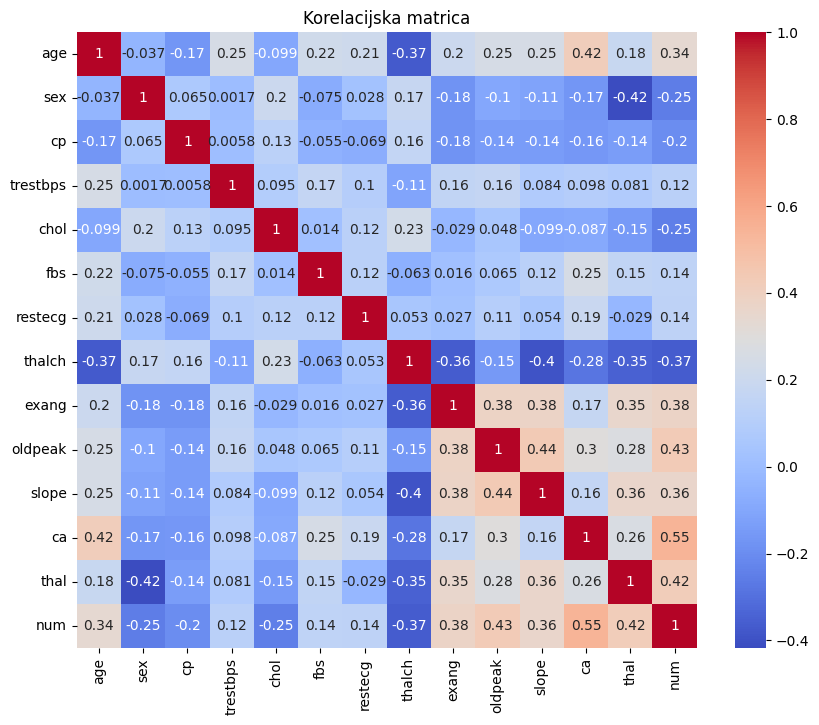

In [15]:
corr_matrix = dataset5.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Korelacijska matrica")
plt.show()

Iz ovoga možemo zaključiti npr. da 'ca' i ciljna varijabla 'num' imaju značajan porporcionalan odnos, što znači da ako je veća vrijednost za količinu obojenih vena kod fluoroskopije, onda je i veća vjerojatnost da izlazna varijabla poprimi vrijednost 1, tj. da se osobi dijagnosticira bolest zatajenja srca. Također, 'oldpeak' i ciljna varijabla imaju korelaciju od 0.43, što znači da depresija ST segmenta ima pozitivnu korelaciju s postojanjem bolesti ili zatajenja srca.

Također, 'thalch' i 'age' imaju negativni iznos korelacije od -0.37, što ukazuje da se s povećanjem godina smanjuju maksimalni otkucaji srca. Također, 'thalch' s 'num' ima negativnu korelaciju, što ukazuje da niži maksimalni otkucaji srca mogu biti povezani s većim rizikom od srčane bolesti.

Po korelacijskoj matrici onda možemo vidjeti da varijable 'ca', 'oldpeak', 'slope', 'thal' imaju jaku korelaciju s ciljnom varijablom 'num'.

In [16]:
dataset6 = pd.DataFrame(
    MinMaxScaler().fit(dataset4).inverse_transform(dataset5),
    columns=dataset5.columns
)

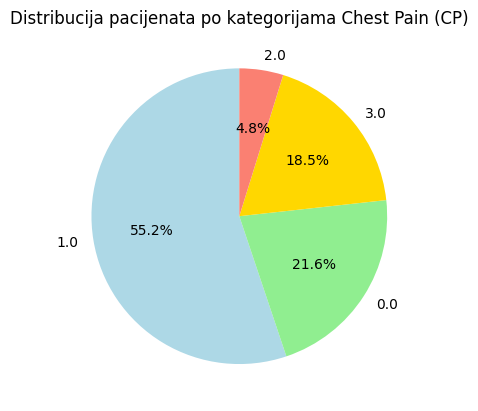

In [17]:
cp_counts = dataset6['cp'].value_counts()

plt.pie(cp_counts, labels=cp_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'gold', 'salmon'])
plt.title('Distribucija pacijenata po kategorijama Chest Pain (CP)')
plt.show()

U pitnom grafu možemo vidjeti koliko je pacijenata bilo sa zabilježenim bolovima u prsima i, ako da, koliko jakim (0 znači da nisu imali bolove, a 3 znači da su imaki jake bolove).

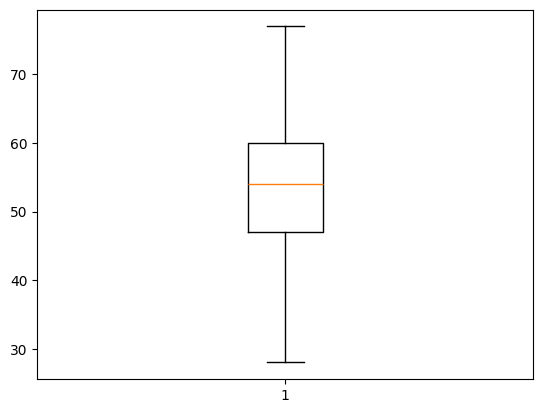

In [18]:
plt.boxplot(dataset6.age)
plt.show()

Vidimo da je skup podataka prikupljen na osobama koje su između kasnijih dvadesetih i kasnijih sedamdesetih godina.

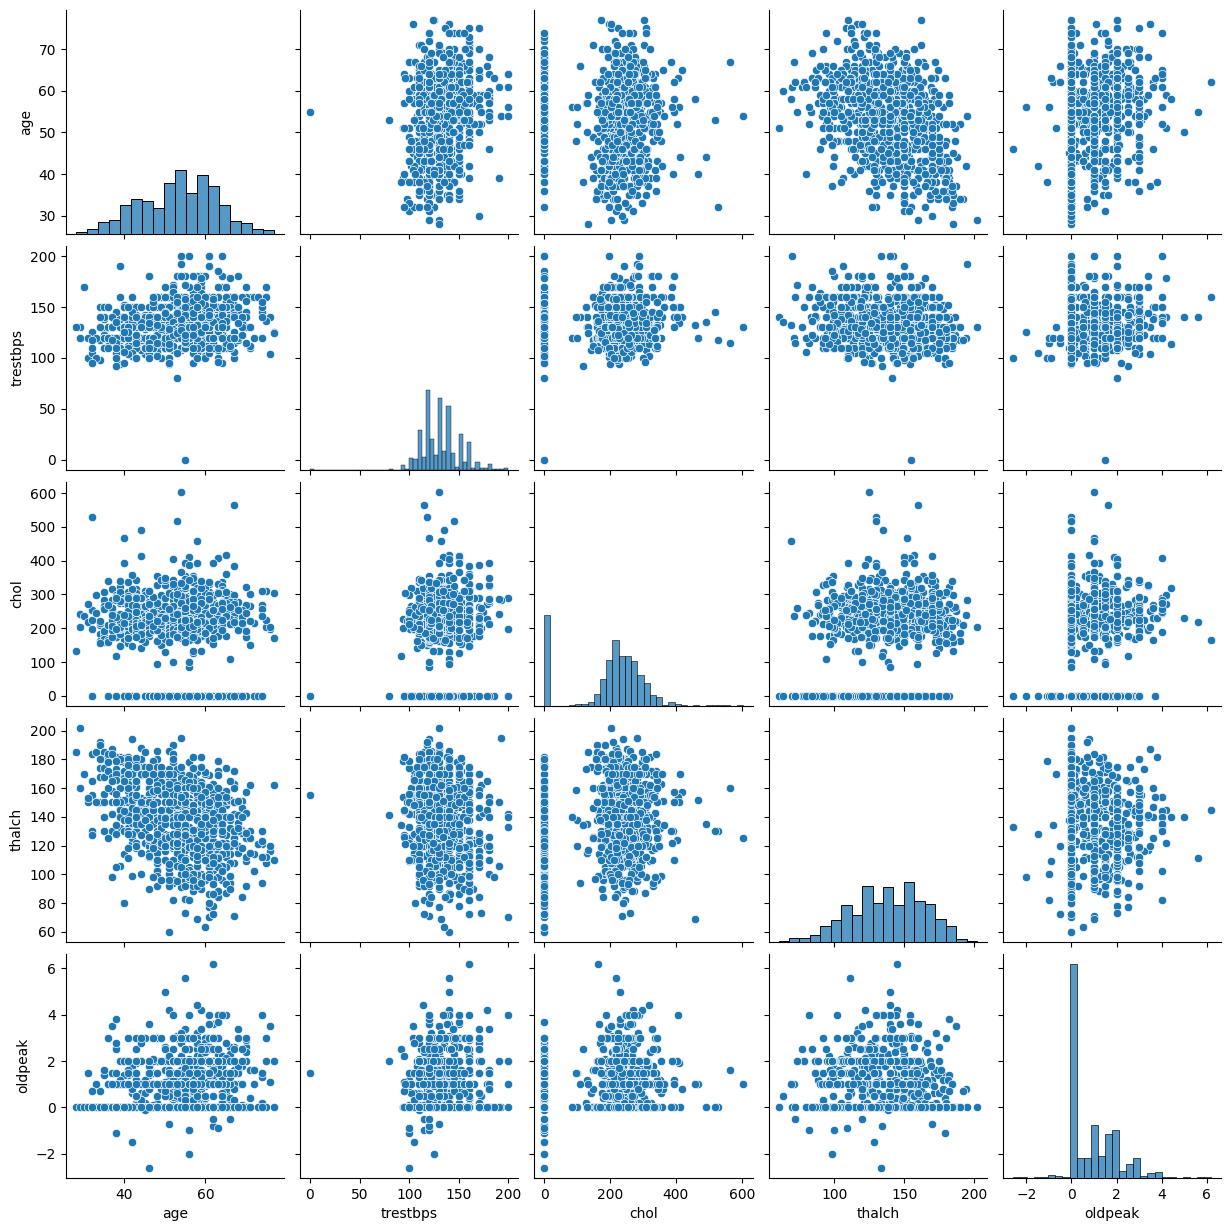

In [19]:
sns.pairplot(dataset6[["age", "trestbps", "chol", "thalch", "oldpeak"]])
plt.show()

Grafovi na dijagonali nam općenito pokazuju distribuciju svake pojedine varijable. Možemo vidjeti da 'age' i 'thalch' imaju približno normalnu distribuciju.

Scatterplottovi izvan dijagonala prikazuju međusobne odnose dviju varijabli. Tako npr. možemo vidjeti da ne postoji neka jasna korelacija između starosti i razine kolesterola, što je jasno i iz matrice korelacije. Onda možemo vidjeti i da postoji jasna korelacija između 'thalch' i 'age' i možemo zaključiti da stariji pacijenti generalno imaju niži broj maksimalnih otkucaja srca.

Općenito, možemo reći da većina podataka nije jako linearno povezana, te da određene varijable imaju outliere koji bi mogli utjecati na određene modele strojnog učenja pri kasnijem postupku njihovog treniranja i testiranja.

**Treći dio projekta: Strojno učenje**

In [20]:
dataset7 = dataset6.copy()
dataset7['num'] = (dataset7['num'] >= 1).astype(int)

Pretvorili smo sve vrijednosti veće ili jednako 1 u značajki 'num' u 1, dok su sve vrijendosti 0 ostale iste.

In [21]:
dataset7.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63.0,0.0,2.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,2.0,0.0,2.0,0
1,67.0,0.0,1.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,1.0,3.0,0.0,1
2,67.0,0.0,1.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1.0,2.0,1.0,1
3,37.0,0.0,0.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,2.0,0.0,0.0,0
4,41.0,1.0,3.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0.0,0.0,0.0,0


In [22]:
from sklearn.model_selection import train_test_split

X = dataset7.drop(columns=['num'])
y = dataset7['num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Podijelili smo train i testni skup podataka u omjeru 80% naspram 20%.

In [23]:
print(y.value_counts())

num
1    463
0    371
Name: count, dtype: int64


**Decision tree**

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier(random_state=42)
model_DT.fit(X_train, y_train)

y_train_pred_DT = model_DT.predict(X_train)

print(f'F1 = {f1_score(y_train, y_train_pred_DT)}')
print(f'Acc = {accuracy_score(y_train, y_train_pred_DT)}')
confusion_matrix(y_train, y_train_pred_DT)

F1 = 1.0
Acc = 1.0


array([[297,   0],
       [  0, 370]])

Class Precision (1): 80.21%
Class Precision (0): 77.46%
Class Recall (1): 82.80%
Class Recall (0): 74.32%
F1 = 0.8148148148148148
Acc = 0.7904191616766467


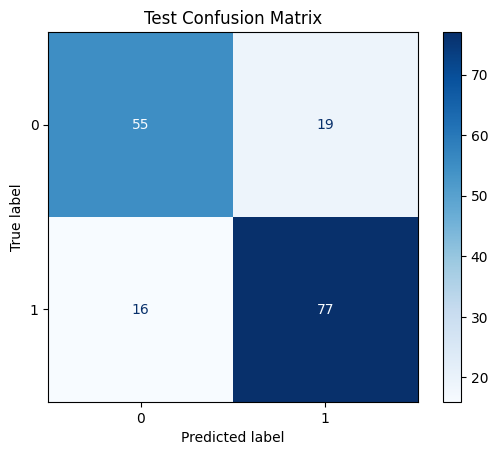

In [25]:
y_test_pred_DT = model_DT.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_DT)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_DT)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_DT)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_DT), display_labels=model_DT.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

Najbolji hiperparametri: {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
F1 score (Train): 0.8875569527975213
Accuracy (Train): 0.889055472263868
F1 score (Test): 0.8407423708920188
Accuracy (Test): 0.844311377245509

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.85      0.78      0.82        74
           1       0.84      0.89      0.86        93

    accuracy                           0.84       167
   macro avg       0.85      0.84      0.84       167
weighted avg       0.84      0.84      0.84       167



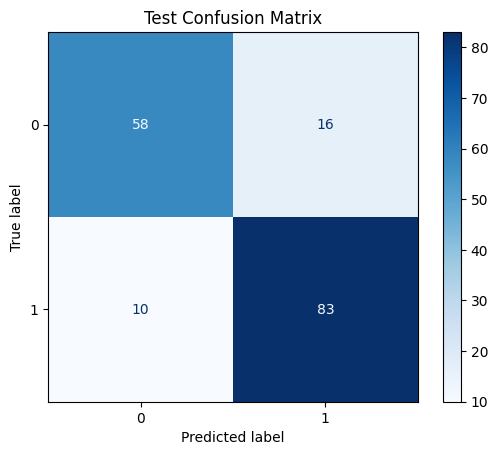

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.01, 0.1, 0.5],
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print(f"Najbolji hiperparametri: {grid_search.best_params_}")
print(f"F1 score (Train): {f1_score(y_train, y_train_pred, average='macro')}")
print(f"Accuracy (Train): {accuracy_score(y_train, y_train_pred)}")
print(f"F1 score (Test): {f1_score(y_test, y_test_pred, average='macro')}")
print(f"Accuracy (Test): {accuracy_score(y_test, y_test_pred)}")
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred), display_labels=best_model.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

Optimizacijom smo uspjeli doći do F1 od 84,07% i *Accuracy* od 84,43%. U usporedbi s člankom, naši *class recall* i *class precision* su relativno sličnih vrijednosti, dok naš model postiže manji *Accuracy*, što može biti zato što smo uzeli veći omjer iz dataset-a kao skup za učenje, dok je u članku korišten omjer 95% primjera iz dataset-a čini *train skup* naspram 5% *test skup*. To je preveliki omjer pa model koji i možda lošije klasificira ima bolji *Accuracy* jer ima manji skup na kojem može pogriješiti, pa makar i sve primjere trpao u istu klasu. Također je kao mjera točnosti kalsifikacije korištena samo mjera *Accuracy*, koja "naglašava" točno klasificirane primjere puno više nego one pogrešne, zbog čega rezultati klasifikacije izgledaju još i bolje nego stvarno jesu, dok mi koristimo i mjeru F1, koja uzima u obzir i točno klasificirane i netočno klasificirane primjere.

**Naivni Bayesov klasifikator**

In [27]:
from sklearn.naive_bayes import GaussianNB

model_NB = GaussianNB()
model_NB.fit(X_train, y_train)

y_train_pred_NB = model_NB.predict(X_train)

print(f'F1 = {f1_score(y_train, y_train_pred_NB)}')
print(f'Acc = {accuracy_score(y_train, y_train_pred_NB)}')
confusion_matrix(y_train, y_train_pred_NB)

F1 = 0.8528610354223434
Acc = 0.8380809595202399


array([[246,  51],
       [ 57, 313]])

Class Precision (1): 80.41%
Class Precision (0): 78.57%
Class Recall (1): 83.87%
Class Recall (0): 74.32%
F1 = 0.8210526315789474
Acc = 0.7964071856287425


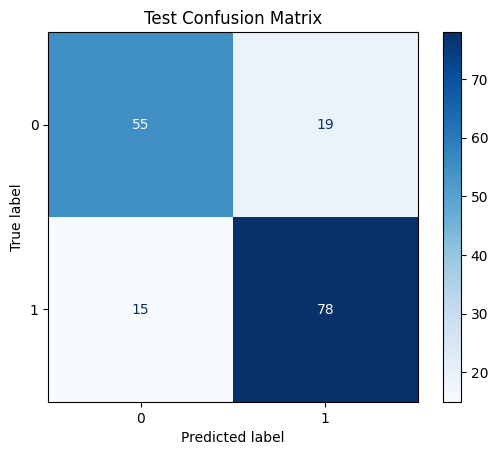

In [28]:
y_test_pred_NB = model_NB.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_NB)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_NB)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_NB)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_NB), display_labels=model_NB.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

Best var_smoothing: {'var_smoothing': np.float64(4.977023564332114e-06)}
Class Precision (1): 80.81%
Class Precision (0): 80.88%
Class Recall (1): 86.02%
Class Recall (0): 74.32%
F1 = 0.8333333333333334
Acc = 0.8083832335329342


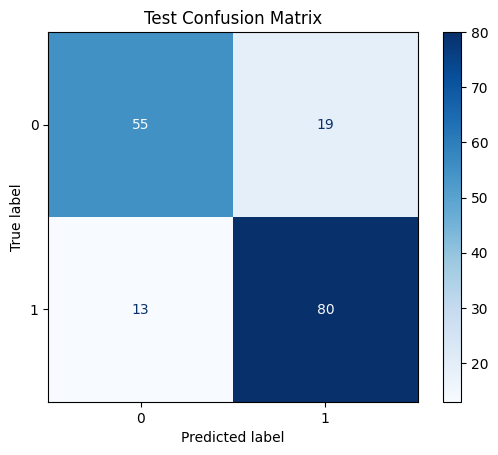

In [29]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {'var_smoothing': np.logspace(-15, -3, 100)}

random_search = RandomizedSearchCV(model_NB, param_distributions=param_grid,
                                   n_iter=20, cv=5, scoring='f1', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

best_NB = random_search.best_estimator_
print(f'Best var_smoothing: {random_search.best_params_}')

y_train_pred_NB = best_NB.predict(X_train)
y_test_pred_NB = best_NB.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_NB)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_NB)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_NB)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_NB), display_labels=model_NB.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

Kod naivnog Bayesa smo koristili Gaussov Bayesov klasifikator i postigli malo slabije rezultate (čitaj: unutar 12%) za *class recall* i *class precision*, ali je sveukupan *Accuracy* iznad 80%, a mjera F1 još i bolja (što je i bitnije) od 83,33%. U usporedbi s člankom su dosta dobri rezultati.

**Random forest**

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Random Forest")
print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")

f1_train = f1_score(y_train, y_train_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

print(f"F1 score (train): {f1_train:.2f}")
print(f"F1 score (test): {f1_test:.2f}")

Random Forest
Train accuracy: 1.00
Test accuracy: 0.84
F1 score (train): 1.00
F1 score (test): 0.84


C:\Users\Lucija\AppData\Roaming\Python\Python311\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Optimized Random Forest
Best parameters: {'criterion': 'gini', 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Class Precision (0): 85.51%
Class Precision (1): 84.69%
Class Recall (0): 79.73%
Class Recall (1): 89.25%
F1 = 0.8496
Acc = 0.8503


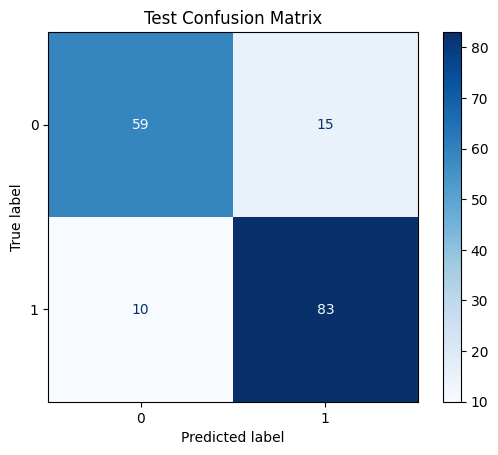

In [31]:
param_grid = {
    'n_estimators': [100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                            param_grid,
                            cv=5,
                            scoring='f1_weighted',
                            n_jobs=-1,
                            refit=True)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_test_pred_opt = best_model.predict(X_test)

f1_test_opt = f1_score(y_test, y_test_pred_opt, average='weighted')

print("Optimized Random Forest")
print(f"Best parameters: {grid_search.best_params_}")

test_accuracy_opt = accuracy_score(y_test, y_test_pred_opt)

precision_class_0 = precision_score(y_test, y_test_pred_opt, average=None)[0] * 100
precision_class_1 = precision_score(y_test, y_test_pred_opt, average=None)[1] * 100
recall_class_0 = recall_score(y_test, y_test_pred_opt, average=None)[0] * 100
recall_class_1 = recall_score(y_test, y_test_pred_opt, average=None)[1] * 100

print(f"Class Precision (0): {precision_class_0:.2f}%")
print(f"Class Precision (1): {precision_class_1:.2f}%")
print(f"Class Recall (0): {recall_class_0:.2f}%")
print(f"Class Recall (1): {recall_class_1:.2f}%")
print(f"F1 = {f1_test_opt:.4f}")
print(f"Acc = {test_accuracy_opt:.4f}")

cm = confusion_matrix(y_test, y_test_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

Random forrest nam je također imao približno iste rezultate kao i u članku, pogotovo kada se uzme u obzir ono što je već spomenuto kod modela Decision tree, što generalno vrijedi za sve naše rezultate u usporedbi s njihovim rezultatima. F1 mjera od 85% ukazuje na visoku pouzdanost klasifikacije.

**Logistic regression**

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=5000)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Logistic Regression")
print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")

f1_train = f1_score(y_train, y_train_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

print(f"F1 score (train): {f1_train:.2f}")
print(f"F1 score (test): {f1_test:.2f}")

Logistic Regression
Train accuracy: 0.84
Test accuracy: 0.83
F1 score (train): 0.84
F1 score (test): 0.83


Optimized Logistic Regression
Best parameters: {'C': np.float64(0.1), 'penalty': 'l2', 'solver': 'liblinear'}
Class Precision (0): 82.35%
Class Recall (0): 75.68%
Class Precision (1): 81.82%
Class Recall (1): 87.10%
F1 = 0.8194
Acc = 0.8204


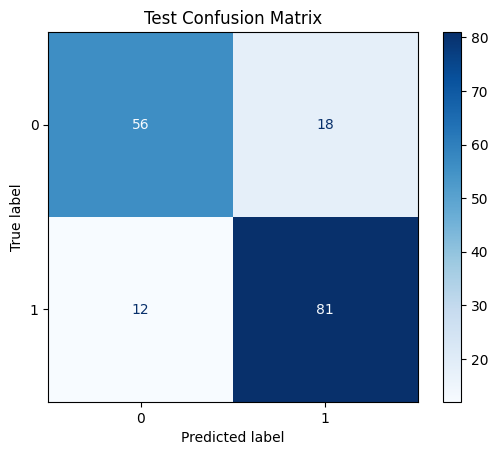

In [33]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': np.logspace(-3, 3, 7),
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(LogisticRegression(random_state=42, max_iter=5000),
                           param_grid,
                           cv=5,
                           scoring='f1_weighted',
                           n_jobs=-1,
                           refit=True)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_test_pred_opt = best_model.predict(X_test)

f1_test_opt = f1_score(y_test, y_test_pred_opt, average='weighted')

print("Optimized Logistic Regression")
print(f"Best parameters: {grid_search.best_params_}")

test_accuracy_opt = accuracy_score(y_test, y_test_pred_opt)

precision_per_class = precision_score(y_test, y_test_pred_opt, average=None)
recall_per_class = recall_score(y_test, y_test_pred_opt, average=None)

for i, (prec, rec) in enumerate(zip(precision_per_class, recall_per_class)):
    print(f"Class Precision ({i}): {prec * 100:.2f}%")
    print(f"Class Recall ({i}): {rec * 100:.2f}%")

print(f"F1 = {f1_test_opt:.4f}")
print(f"Acc = {test_accuracy_opt:.4f}")

cm = confusion_matrix(y_test, y_test_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

Sada već možemo uvidjeti da su kod nas veći problemi kada je u pitanju klasifikacija negativnih primjera (klasa 0) naspram klase 1. To nam je u realnom slučaju bolje nego da je situacija obrnuta jer to znači da su veće šanse da se osoba koja nema rizik od zatajenja srca klasificira kao da ima, pa se lako dodatnim pretragama ustanovi da je klasificirana kao lažno pozitivni primjer. Dok je točnost klasifikacije za pozitivne primjere točnija, što nam je bitno da nam ne promakne osoba koja ima potencijala za oboljenje od zatajenja srca.

**SVM**

In [34]:
from sklearn.svm import SVC

model_SVM = SVC()
model_SVM.fit(X_train, y_train)

y_train_pred_SVM = model_SVM.predict(X_train)

print(f'F1 = {f1_score(y_train, y_train_pred_SVM)}')
print(f'Acc = {accuracy_score(y_train, y_train_pred_SVM)}')
confusion_matrix(y_train, y_train_pred_SVM)

F1 = 0.7444444444444445
Acc = 0.7241379310344828


array([[215,  82],
       [102, 268]])

Class Precision (1): 73.91%
Class Precision (0): 66.67%
Class Recall (1): 73.12%
Class Recall (0): 67.57%
F1 = 0.7351351351351352
Acc = 0.7065868263473054


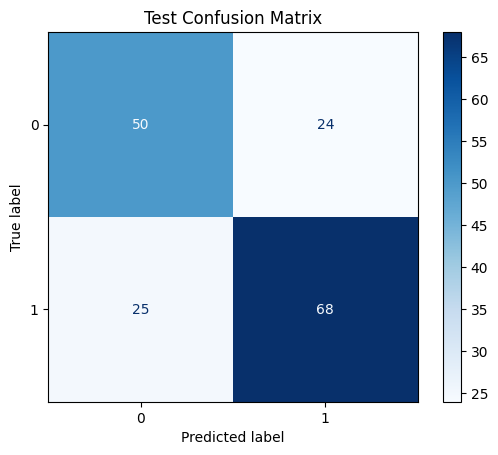

In [35]:
y_test_pred_SVM= model_SVM.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_SVM)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_SVM)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_SVM)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_SVM), display_labels=model_SVM.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

F1 (train) = 0.852054794520548
Acc (train) = 0.8380809595202399
Class Precision (1) Opt: 82.80%
Class Precision (0) Opt: 78.38%
Class Recall (1) Opt: 82.80%
Class Recall (0) Opt: 78.38%
F1 (test) = 0.8279569892473119
Acc (test) = 0.8083832335329342


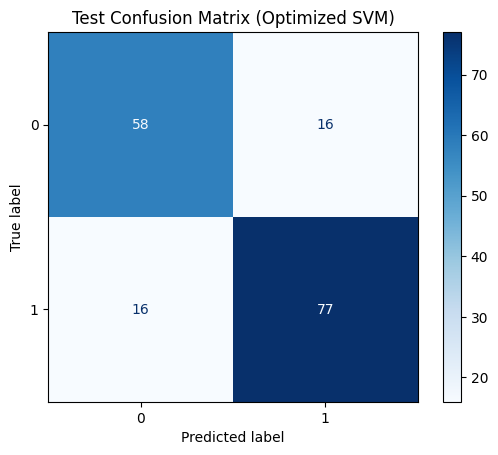

In [36]:
from sklearn.svm import SVC
import scipy.stats as stats

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

model_SVM_optimized = RandomizedSearchCV(SVC(class_weight='balanced'), param_distributions=param_grid,
                                         n_iter=5, cv=3, scoring='roc_auc', n_jobs=-1, random_state=42)


model_SVM_optimized.fit(X_train, y_train)

best_SVM = model_SVM_optimized.best_estimator_

y_train_pred_SVM_opt = best_SVM.predict(X_train)

print(f'F1 (train) = {f1_score(y_train, y_train_pred_SVM_opt)}')
print(f'Acc (train) = {accuracy_score(y_train, y_train_pred_SVM_opt)}')

y_test_pred_SVM_opt = best_SVM.predict(X_test)

cm_opt = confusion_matrix(y_test, y_test_pred_SVM_opt)

TP_opt = cm_opt[1, 1]
FP_opt = cm_opt[0, 1]
FN_opt = cm_opt[1, 0]
TN_opt = cm_opt[0, 0]

precision_1_opt = TP_opt / (TP_opt + FP_opt) * 100
precision_0_opt = TN_opt / (TN_opt + FN_opt) * 100
recall_1_opt = TP_opt / (TP_opt + FN_opt) * 100
recall_0_opt = TN_opt / (TN_opt + FP_opt) * 100

print(f'Class Precision (1) Opt: {precision_1_opt:.2f}%')
print(f'Class Precision (0) Opt: {precision_0_opt:.2f}%')
print(f'Class Recall (1) Opt: {recall_1_opt:.2f}%')
print(f'Class Recall (0) Opt: {recall_0_opt:.2f}%')
print(f'F1 (test) = {f1_score(y_test, y_test_pred_SVM_opt)}')
print(f'Acc (test) = {accuracy_score(y_test, y_test_pred_SVM_opt)}')

disp_test_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=best_SVM.classes_)
disp_test_opt.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix (Optimized SVM)')
plt.show()

Model SVM kod nas ima možda najveću razliku s obzirom na klasifikaciju istog modela u članku, što je moguće i zbog zahtjevnosti optimizacije ovog modela. Naime, pošto je model SVM vrlo raznovrstan i može se koristiti u obliku različitih funkcija, postoji i puno hiperparametara koji se mogu optimizirati i puno kombinacija istih koje se moraju isprobati kod njihove optimizacije. Pošto smo studenti kojima su jedine opcije korištenje vlastitih laptopa i/ili google collaba, bili smo ograničeni s brojem iteracija i etapama cross validationa koje smo mogli provrtiti pri optimizaciji. Tako da su ovo najbolji rezultati koje smo mi mogli dobiti.

*dodatno*: **K-Nearest Neighbour**

In [37]:
from sklearn.neighbors import KNeighborsClassifier

model_NKN = KNeighborsClassifier()
model_NKN.fit(X_train, y_train)

y_train_pred_NKN = model_NKN.predict(X_train)

print(f'F1 = {f1_score(y_train, y_train_pred_NKN)}')
print(f'Acc = {accuracy_score(y_train, y_train_pred_NKN)}')
confusion_matrix(y_train, y_train_pred_NKN)

F1 = 0.820855614973262
Acc = 0.7991004497751124


array([[226,  71],
       [ 63, 307]])

Class Precision (1): 67.74%
Class Precision (0): 59.46%
Class Recall (1): 67.74%
Class Recall (0): 59.46%
F1 = 0.6774193548387096
Acc = 0.6407185628742516


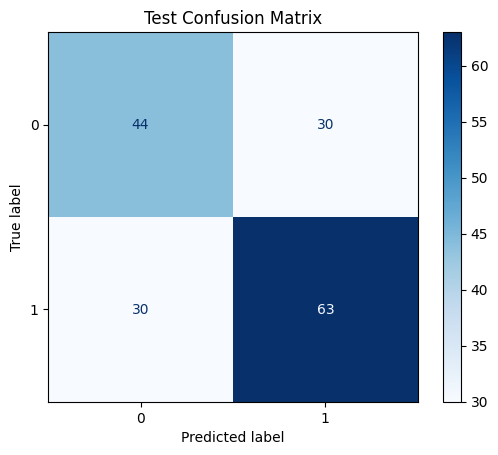

In [38]:
y_test_pred_NKN = model_NKN.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_NKN)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_NKN)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_NKN)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_NKN), display_labels=model_NKN.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

Točnost na trening setu: 1.0000
F1 score na trening setu: 1.0000
[[297   0]
 [  0 370]]
Class Precision (1): 72.63%
Class Precision (0): 66.67%
Class Recall (1): 74.19%
Class Recall (0): 64.86%
F1 = 0.7340425531914894
Acc = 0.7005988023952096


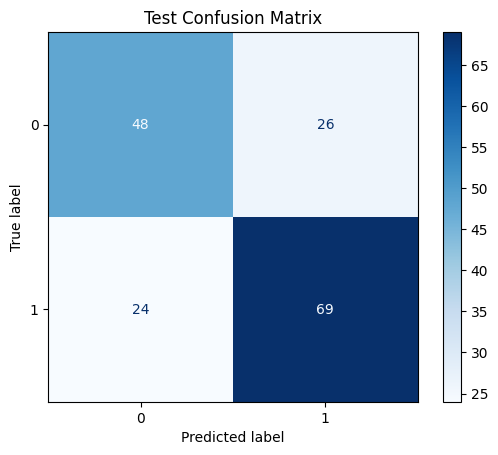

In [39]:
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [20, 30, 40],
    'p': [1, 2]
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_train_pred_NKN = best_model.predict(X_train)
print(f'Točnost na trening setu: {accuracy_score(y_train, y_train_pred_NKN):.4f}')
print(f'F1 score na trening setu: {f1_score(y_train, y_train_pred_NKN):.4f}')
print(confusion_matrix(y_train, y_train_pred_NKN))

y_test_pred_NKN = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred_NKN)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_NKN)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_NKN)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_NKN), display_labels=model_NKN.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

Pokušali smo dodatno i istrenirati model K-Nearest neighbours na ovom skupu podataka. Prije optimizacije je model dosta loše klasificirao, a nakon optimizacije okej klasificira, ali nije baš najbolja opcija naspram drugih dosadašnjih modela koje smo koristili. Kao što vidimo, posebno ga muče slučajevi kada je klasifikacija 0. Moguće da je to zato što su klase općenito blago neuravnotežene pošto prije podjele na trening i testni skup postoji 463 primjera za klasu 1, dok je za klasu 0 količina primjera za 100 manje, pa je omjer klasa 0:1 jednak 3:4... TO možda nije toliko značajna razlika, ali će ona biti izraženiija kod manjih skupa podataka.

*dodatno*: **Višeklasni problem**

In [40]:
dataset6.head(15)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63.0,0.0,2.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,2.0,0.0,2.0,0.0
1,67.0,0.0,1.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,1.0,3.0,0.0,2.0
2,67.0,0.0,1.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1.0,2.0,1.0,1.0
3,37.0,0.0,0.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,2.0,0.0,0.0,0.0
4,41.0,1.0,3.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0.0,0.0,0.0,0.0
5,56.0,0.0,3.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,0.0,0.0,0.0,0.0
6,62.0,1.0,1.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,2.0,2.0,0.0,3.0
7,57.0,1.0,1.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,0.0,0.0,0.0,0.0
8,63.0,0.0,1.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,1.0,1.0,1.0,2.0
9,53.0,0.0,1.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,2.0,0.0,1.0,1.0


In [41]:
X = dataset6.drop(columns=['num'])
y = dataset6['num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(y.value_counts())

num
0.0    371
1.0    246
2.0    100
3.0     92
4.0     25
Name: count, dtype: int64


Podijelili smo skup podataka tako da je omjer train i testnih podataka 70:30.

Accuracy: 0.5816733067729084
Class Precision (1) Opt: 70.31%
Class Precision (0) Opt: 80.00%
Class Recall (1) Opt: 66.18%
Class Recall (0) Opt: 82.88%
F1 (test) = 0.546043065169134
Acc (test) = 0.5816733067729084


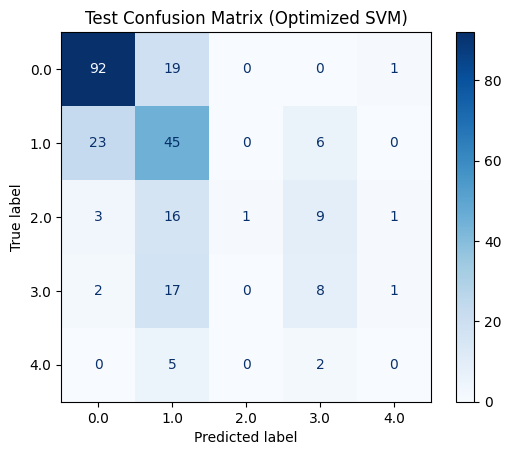

In [42]:
svm_model = SVC(kernel='linear', decision_function_shape='ovr', random_state=42)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

cm_opt = confusion_matrix(y_test, y_pred)

TP_opt = cm_opt[1, 1]
FP_opt = cm_opt[0, 1]
FN_opt = cm_opt[1, 0]
TN_opt = cm_opt[0, 0]

precision_1_opt = TP_opt / (TP_opt + FP_opt) * 100
precision_0_opt = TN_opt / (TN_opt + FN_opt) * 100
recall_1_opt = TP_opt / (TP_opt + FN_opt) * 100
recall_0_opt = TN_opt / (TN_opt + FP_opt) * 100

print(f'Class Precision (1) Opt: {precision_1_opt:.2f}%')
print(f'Class Precision (0) Opt: {precision_0_opt:.2f}%')
print(f'Class Recall (1) Opt: {recall_1_opt:.2f}%')
print(f'Class Recall (0) Opt: {recall_0_opt:.2f}%')
print(f'F1 (test) = {f1_score(y_test, y_pred, average="weighted")}')
print(f'Acc (test) = {accuracy_score(y_test, y_pred)}')

disp_test_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=svm_model.classes_)
disp_test_opt.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix (Optimized SVM)')
plt.show()

Accuracy: 0.5816733067729084
Class Precision (1) Opt: 70.31%
Class Precision (0) Opt: 80.00%
Class Recall (1) Opt: 66.18%
Class Recall (0) Opt: 82.88%
F1 (test) = 0.546043065169134
Acc (test) = 0.5816733067729084


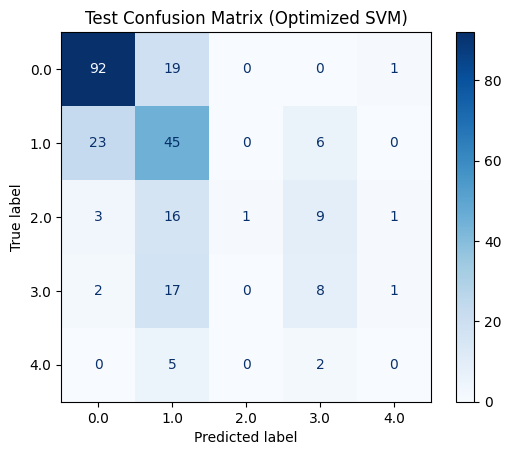

In [43]:
svm_model = SVC(kernel='linear', decision_function_shape='ovo', random_state=42)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

cm_opt = confusion_matrix(y_test, y_pred)

TP_opt = cm_opt[1, 1]
FP_opt = cm_opt[0, 1]
FN_opt = cm_opt[1, 0]
TN_opt = cm_opt[0, 0]

precision_1_opt = TP_opt / (TP_opt + FP_opt) * 100
precision_0_opt = TN_opt / (TN_opt + FN_opt) * 100
recall_1_opt = TP_opt / (TP_opt + FN_opt) * 100
recall_0_opt = TN_opt / (TN_opt + FP_opt) * 100

print(f'Class Precision (1) Opt: {precision_1_opt:.2f}%')
print(f'Class Precision (0) Opt: {precision_0_opt:.2f}%')
print(f'Class Recall (1) Opt: {recall_1_opt:.2f}%')
print(f'Class Recall (0) Opt: {recall_0_opt:.2f}%')
print(f'F1 (test) = {f1_score(y_test, y_pred, average="weighted")}')
print(f'Acc (test) = {accuracy_score(y_test, y_pred)}')

disp_test_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=svm_model.classes_)
disp_test_opt.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix (Optimized SVM)')
plt.show()

Prvo smo htjeli usporediti kako bi linearni SVM funkcionirao sa shemama One-vs-Rest i One-vs-One na višeklasnom problemu, pošto OVR shema obično ima problema s neuravnoteženosti klasa. No, u našem slučaju su rezultati ispali isti pa nismo imali priliku vidjeti taj fenomen.

F1 (train) = 0.6113311585788342
Acc (train) = 0.6037735849056604
F1 (test) = 0.5446702358977785
Acc (test) = 0.5298804780876494


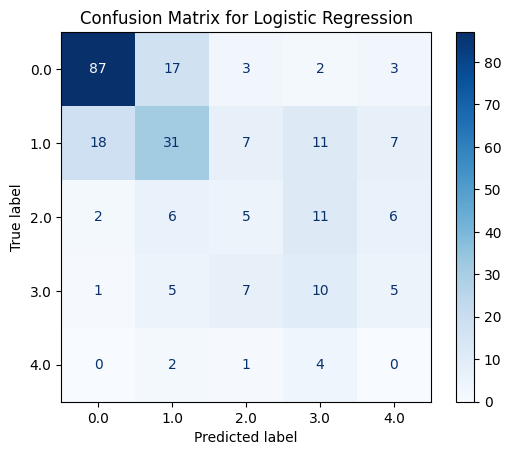

Razdioba klasa u trening skupu:
num
0.0    259
1.0    172
2.0     70
3.0     64
4.0     18
Name: count, dtype: int64
Razdioba klasa u test skupu:
num
0.0    112
1.0     74
2.0     30
3.0     28
4.0      7
Name: count, dtype: int64


In [44]:
model_LR = LogisticRegression(class_weight='balanced', random_state=42, max_iter=100000)
model_LR.fit(X_train, y_train)

y_train_pred_LR = model_LR.predict(X_train)
y_test_pred_LR = model_LR.predict(X_test)

print(f'F1 (train) = {f1_score(y_train, y_train_pred_LR, average="weighted")}')
print(f'Acc (train) = {accuracy_score(y_train, y_train_pred_LR)}')

print(f'F1 (test) = {f1_score(y_test, y_test_pred_LR, average="weighted")}')
print(f'Acc (test) = {accuracy_score(y_test, y_test_pred_LR)}')

cm = confusion_matrix(y_test, y_test_pred_LR)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_LR.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

print(f'Razdioba klasa u trening skupu:\n{y_train.value_counts()}')
print(f'Razdioba klasa u test skupu:\n{y_test.value_counts()}')

Model logističke regresije nije baš bio nešto bolji, izgleda da ga dosta muči neuravnoteženost klasa. 

Best hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}
F1 (train) = 1.0
Acc (train) = 1.0
F1 (test) = 0.6078330924827292
Acc (test) = 0.6135458167330677


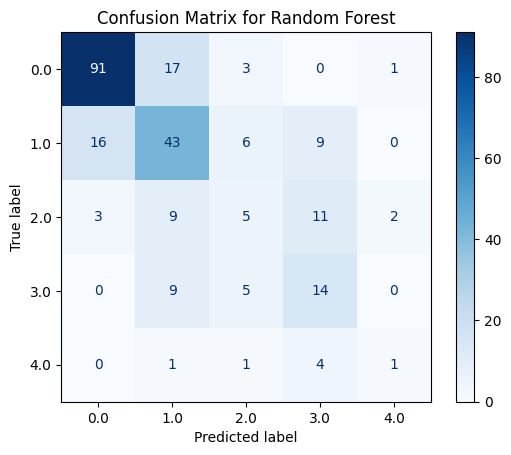

Razdioba klasa u test skupu:
num
0.0    112
1.0     74
2.0     30
3.0     28
4.0      7
Name: count, dtype: int64


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

model_RF = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(model_RF, param_distributions=param_dist, 
                                   n_iter=100, scoring='f1_weighted', 
                                   cv=5, random_state=42, n_jobs=-1)
random_search.fit(X_train_res, y_train_res)

print(f'Best hyperparameters: {random_search.best_params_}')

best_model = random_search.best_estimator_

y_train_pred_RF = best_model.predict(X_train_res)
print(f'F1 (train) = {f1_score(y_train_res, y_train_pred_RF, average="weighted")}')
print(f'Acc (train) = {accuracy_score(y_train_res, y_train_pred_RF)}')

y_test_pred_RF = best_model.predict(X_test_scaled)
print(f'F1 (test) = {f1_score(y_test, y_test_pred_RF, average="weighted")}')
print(f'Acc (test) = {accuracy_score(y_test, y_test_pred_RF)}')

cm = confusion_matrix(y_test, y_test_pred_RF)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest')
plt.show()

print(f'Razdioba klasa u test skupu:\n{y_test.value_counts()}')

Model Random foresta je već malo bolji te je dosegao F1 od 60%, što i dalje nije puno, ali moguće je da ga muči mali skup podataka pa da bi bio još bolji s većim skupom podataka.

Najbolji parametri: {'weights': 'distance', 'n_neighbors': np.int64(5), 'metric': 'manhattan'}
F1 (train) = 1.0000
Acc (train) = 1.0000
F1 (test) = 0.6377
Acc (test) = 0.6429


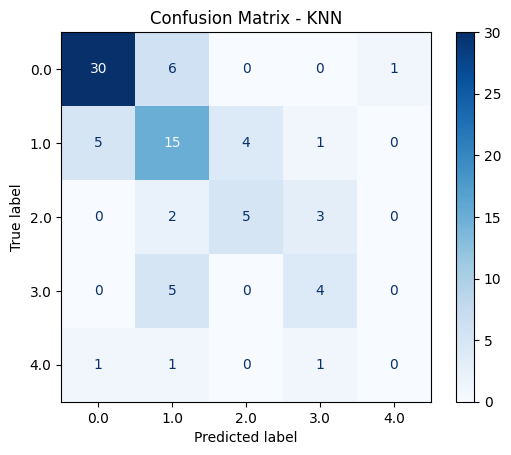

In [46]:
X = dataset6.drop(columns=['num'])
y = dataset6['num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier()

param_dist = {
    'n_neighbors': np.arange(1, 31, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

random_search = RandomizedSearchCV(knn, param_dist, n_iter=30, cv=5, scoring='f1_weighted', random_state=42, n_jobs=-1)
random_search.fit(X_train_scaled, y_train)

best_knn = random_search.best_estimator_
print(f'Najbolji parametri: {random_search.best_params_}')

y_train_pred = best_knn.predict(X_train_scaled)
y_test_pred = best_knn.predict(X_test_scaled)

print(f'F1 (train) = {f1_score(y_train, y_train_pred, average="weighted"):.4f}')
print(f'Acc (train) = {accuracy_score(y_train, y_train_pred):.4f}')
print(f'F1 (test) = {f1_score(y_test, y_test_pred, average="weighted"):.4f}')
print(f'Acc (test) = {accuracy_score(y_test, y_test_pred):.4f}')

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - KNN')
plt.show()

Model k-najbližih susjeda je u ovom slučaju ispao kao najbolja opcija, iako kod manjeg skupa za testiranje od 10%. Izgleda da je najveći problem klasa 4, koja i u samom početku prije podjele skupa ima najmanje primjera, pa je modelu teže za naučiti što bi trebalo spadati pod tu klasu pa će i samim time puno rjeđe uopće smjestiti neki primjer u nju.

Zaključno, korištenje ovog skupa podataka za višeklasnu klasifikaciju nije baš najbolja opcija jer je skup sam po sebi malobrojan, čak i kada se pretvori u binarni problem, a kamo li kada ima 5 različitih klasa u koje treba svrstati primjere. Zato su i klasifikacije modela iz te perspektive puno lošije od binarnih klasifikacija. Za bolje klasifikacije potreban je puno veći, ali i potpuniji skup podataka. Veliki su problem predstavljale i NaN vrijednosti još u njegovoj predobradi jer ih je bilo relativno puno, a to također onda konačno utječe i na mogućnosti i točnost klasifikacije, jer su prave zabilježene vrijednosti i potpun dataset uvijek bolji od nadopunjavanja i generiranja tih vrijednosti u procesu predobrade. 